In [1]:
# ============================================================
# PHASE 6 - Core Analysis
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

load_dotenv(r"C:\Users\yipch\ecommerce-analytics-portfolio\.env")

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "3306")
DB_USER = os.getenv("DB_USER", "root")
DB_PASS = os.getenv("DB_PASSWORD", "")
DB_NAME = os.getenv("DB_NAME", "ecommerce_analytics")

conn_str = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine   = create_engine(conn_str, echo=False)

# Output folders
BASE_DIR   = r"C:\Users\yipch\ecommerce-analytics-portfolio"
FIG_DIR    = os.path.join(BASE_DIR, "reports", "figures")
CLEAN_DIR  = os.path.join(BASE_DIR, "data", "processed")

def save_fig(fig, filename):
    """Save plotly figure as HTML for portfolio."""
    path = os.path.join(FIG_DIR, filename)
    fig.write_html(path)
    print(f"  💾 Saved: reports/figures/{filename}")

def read_sql(query):
    """Helper: run SQL → return DataFrame."""
    with engine.connect() as conn:
        return pd.read_sql(text(query), conn)

print("✅ Setup complete. Starting Core Analysis.")

✅ Setup complete. Starting Core Analysis.


In [2]:
# ============================================================
# STEP 2A - Monthly Revenue + Orders Trend
# ============================================================

df_monthly = read_sql("SELECT * FROM vw_monthly_revenue ORDER BY month")

print("📊 Monthly KPIs:")
print(df_monthly[[
    "month","total_orders","total_revenue",
    "avg_order_value","unique_users","buying_users"
]].to_string(index=False))

# ── MoM Growth ──
df_monthly["revenue_growth_pct"] = (
    df_monthly["total_revenue"]
    .pct_change() * 100
).round(2)

df_monthly["order_growth_pct"] = (
    df_monthly["total_orders"]
    .pct_change() * 100
).round(2)

print(f"\n📈 Month-over-Month Growth:")
print(df_monthly[["month","total_revenue","revenue_growth_pct",
                   "total_orders","order_growth_pct"]].to_string(index=False))

📊 Monthly KPIs:
   month  total_orders  total_revenue  avg_order_value  unique_users  buying_users
2019-Nov       12909.0     3856928.12           298.78         49981          6093
2019-Oct       11693.0     3560026.77           304.46         49984          5626

📈 Month-over-Month Growth:
   month  total_revenue  revenue_growth_pct  total_orders  order_growth_pct
2019-Nov     3856928.12                 NaN       12909.0               NaN
2019-Oct     3560026.77                -7.7       11693.0             -9.42


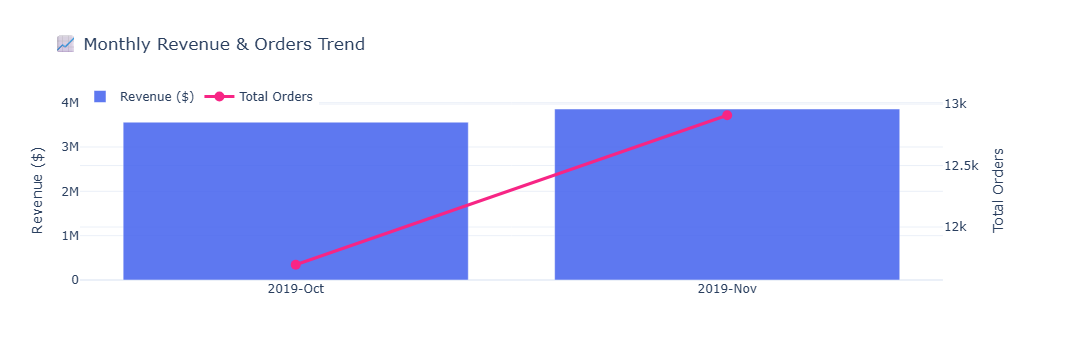

  💾 Saved: reports/figures/01_monthly_revenue_orders.html


In [4]:
# ============================================================
# STEP 2B - Plot: Revenue + Orders dual-axis chart
# ============================================================

# Prepare monthly trend data
df_monthly["month_date"] = pd.to_datetime(df_monthly["month"])

df_monthly = (
    df_monthly
    .sort_values("month_date")
    .reset_index(drop=True)
)
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x    = df_monthly["month"],
        y    = df_monthly["total_revenue"],
        name = "Revenue ($)",
        marker_color = "#4361ee",
        opacity = 0.85,
    ),
    secondary_y = False,
)

fig.add_trace(
    go.Scatter(
        x    = df_monthly["month"],
        y    = df_monthly["total_orders"],
        name = "Total Orders",
        mode = "lines+markers",
        line = dict(color="#f72585", width=3),
        marker = dict(size=10),
    ),
    secondary_y = True,
)

fig.update_layout(
    title    = "📈 Monthly Revenue & Orders Trend",
    template = "plotly_white",
    legend   = dict(orientation="h", y=1.1),
    hovermode = "x unified",
)
fig.update_yaxes(title_text="Revenue ($)",     secondary_y=False)
fig.update_yaxes(title_text="Total Orders",    secondary_y=True)

fig.show()
save_fig(fig, "01_monthly_revenue_orders.html")

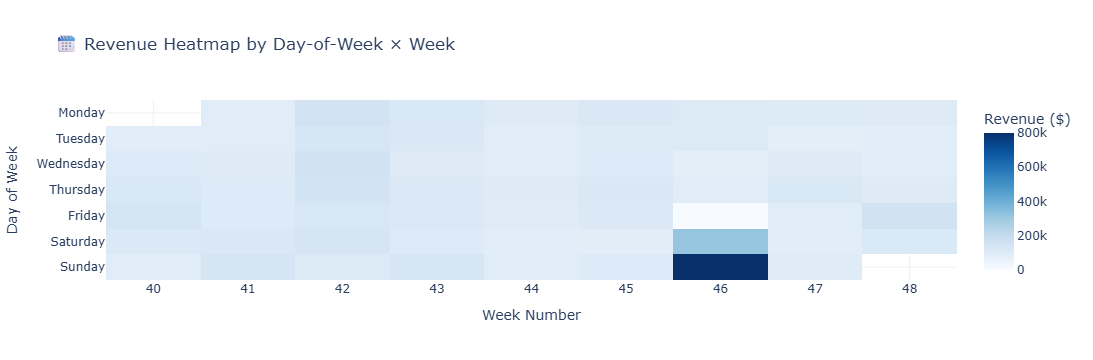

  💾 Saved: reports/figures/02_revenue_heatmap.html


In [5]:
# ============================================================
# STEP 2C - Daily Revenue Heatmap (by day-of-week + week)
# ============================================================

df_daily = read_sql("""
    SELECT * FROM vw_daily_kpis
    ORDER BY full_date
""")

df_daily["full_date"]   = pd.to_datetime(df_daily["full_date"])
df_daily["week"]        = df_daily["full_date"].dt.isocalendar().week.astype(int)
df_daily["day_num"]     = df_daily["full_date"].dt.dayofweek

day_order = ["Monday","Tuesday","Wednesday",
             "Thursday","Friday","Saturday","Sunday"]

pivot = df_daily.pivot_table(
    index   = "day_of_week",
    columns = "week",
    values  = "daily_revenue",
    aggfunc = "sum"
).reindex(day_order)

fig2 = px.imshow(
    pivot,
    labels  = dict(x="Week Number", y="Day of Week", color="Revenue ($)"),
    title   = "🗓️ Revenue Heatmap by Day-of-Week × Week",
    color_continuous_scale = "Blues",
    aspect  = "auto",
)
fig2.update_layout(template="plotly_white")
fig2.show()
save_fig(fig2, "02_revenue_heatmap.html")

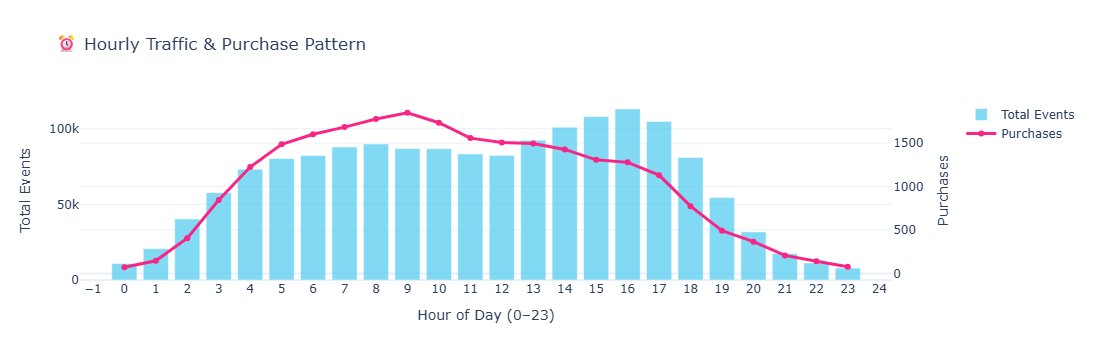

  💾 Saved: reports/figures/03_hourly_pattern.html

🏆 Peak purchase hour : 9:00


In [6]:
# ============================================================
# STEP 2D - Hourly Traffic Pattern
# ============================================================

df_hourly = read_sql("""
    SELECT
        d.`hour`,
        COUNT(*)                                    AS total_events,
        SUM(CASE WHEN f.event_type='purchase'
                 THEN 1 ELSE 0 END)                 AS purchases,
        ROUND(SUM(f.revenue),2)                     AS revenue
    FROM fact_events f
    JOIN dim_date d ON f.date_id = d.date_id
    GROUP BY d.`hour`
    ORDER BY d.`hour`
""")

fig3 = make_subplots(specs=[[{"secondary_y": True}]])

fig3.add_trace(
    go.Bar(
        x    = df_hourly["hour"],
        y    = df_hourly["total_events"],
        name = "Total Events",
        marker_color = "#4cc9f0",
        opacity = 0.7,
    ),
    secondary_y = False,
)

fig3.add_trace(
    go.Scatter(
        x    = df_hourly["hour"],
        y    = df_hourly["purchases"],
        name = "Purchases",
        mode = "lines+markers",
        line = dict(color="#f72585", width=3),
    ),
    secondary_y = True,
)

fig3.update_layout(
    title     = "⏰ Hourly Traffic & Purchase Pattern",
    template  = "plotly_white",
    xaxis     = dict(title="Hour of Day (0–23)", dtick=1),
    hovermode = "x unified",
)
fig3.update_yaxes(title_text="Total Events",  secondary_y=False)
fig3.update_yaxes(title_text="Purchases",     secondary_y=True)

fig3.show()
save_fig(fig3, "03_hourly_pattern.html")

peak_hour = df_hourly.loc[df_hourly["purchases"].idxmax(), "hour"]
print(f"\n🏆 Peak purchase hour : {peak_hour}:00")

📊 Top 10 Categories:
 category_l1  total_views  total_carts  total_purchases  total_revenue  avg_conversion
 electronics     543327.0      31344.0          13585.0     5579546.80            0.49
  appliances     186156.0       5847.0           2570.0      467188.80            0.61
   computers      96171.0       2053.0            922.0      411066.64            0.48
   furniture      46831.0        598.0            297.0       61698.87            0.31
        auto      31103.0        679.0            335.0       44882.79            0.55
        kids      18736.0        322.0            182.0       27694.88            0.42
     apparel      64424.0        692.0            317.0       26314.70            0.26
construction      24517.0        689.0            228.0       24889.49            0.26
       sport       6317.0         92.0             33.0        8079.34            0.25
 accessories       9384.0         95.0             53.0        2022.70            0.22


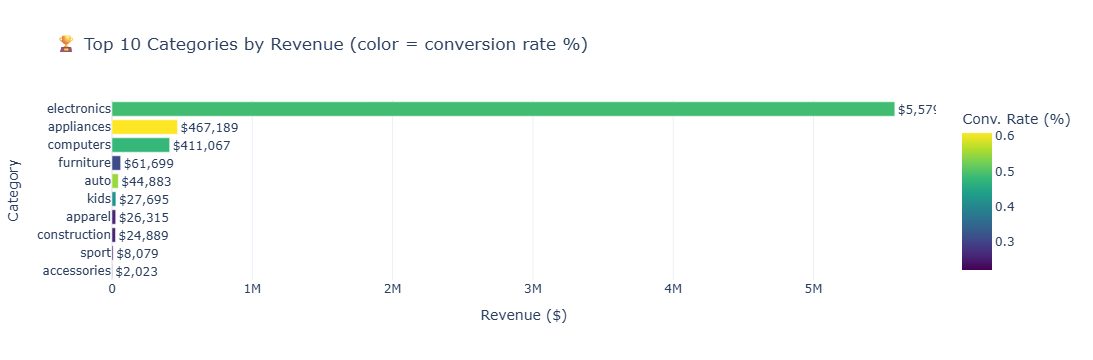

  💾 Saved: reports/figures/04_top_categories.html


In [7]:
# ============================================================
# STEP 3A - Top 10 Categories by Revenue
# ============================================================

df_cat = read_sql("""
    SELECT
        category_l1,
        SUM(views)              AS total_views,
        SUM(carts)              AS total_carts,
        SUM(purchases)          AS total_purchases,
        ROUND(SUM(total_revenue),2) AS total_revenue,
        ROUND(AVG(view_to_purchase_rate),2) AS avg_conversion
    FROM vw_product_performance
    WHERE category_l1 != 'unknown'
    GROUP BY category_l1
    ORDER BY total_revenue DESC
    LIMIT 10
""")

print("📊 Top 10 Categories:")
print(df_cat.to_string(index=False))

fig4 = px.bar(
    df_cat,
    x            = "total_revenue",
    y            = "category_l1",
    orientation  = "h",
    color        = "avg_conversion",
    color_continuous_scale = "Viridis",
    text         = "total_revenue",
    title        = "🏆 Top 10 Categories by Revenue (color = conversion rate %)",
    labels       = {"total_revenue":"Revenue ($)",
                    "category_l1":"Category",
                    "avg_conversion":"Conv. Rate (%)"},
)
fig4.update_traces(texttemplate="$%{text:,.0f}", textposition="outside")
fig4.update_layout(template="plotly_white", yaxis=dict(autorange="reversed"))
fig4.show()
save_fig(fig4, "04_top_categories.html")

📊 Top 10 Brands:
  brand  total_revenue  total_purchases  avg_selling_price  conversion_rate
  apple     3353158.92           4394.0             763.12             3.35
samsung     1442674.68           5119.0             281.83             3.47
 xiaomi      290896.08           1579.0             184.23             1.78
 huawei      127972.78            610.0             209.79             1.83
samsung      104779.15            434.0             241.43             1.93
   acer      100918.30            198.0             509.69             1.24
lucente       98394.30            377.0             260.99             1.53
  apple       96603.06             58.0            1665.57             1.42
   oppo       96030.47            409.0             234.79             2.25
     lg       63116.03            172.0             366.95             1.32


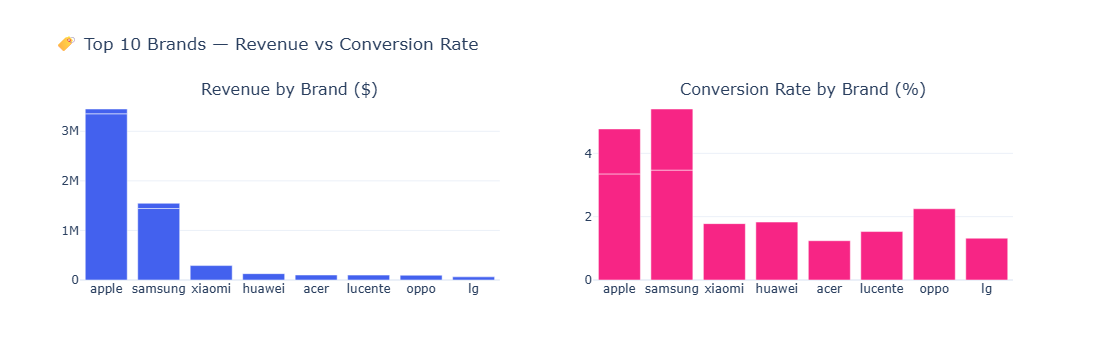

  💾 Saved: reports/figures/05_brand_performance.html


In [8]:
# ============================================================
# STEP 3B - Top 10 Brands by Revenue
# ============================================================

df_brand = read_sql("""
    SELECT *
    FROM vw_brand_performance
    WHERE brand != 'unknown'
    LIMIT 10
""")

print("📊 Top 10 Brands:")
print(df_brand[[
    "brand","total_revenue","total_purchases",
    "avg_selling_price","conversion_rate"
]].to_string(index=False))

fig5 = make_subplots(rows=1, cols=2,
                     subplot_titles=("Revenue by Brand ($)",
                                     "Conversion Rate by Brand (%)"))

fig5.add_trace(
    go.Bar(
        x    = df_brand["brand"],
        y    = df_brand["total_revenue"],
        name = "Revenue",
        marker_color = "#4361ee",
    ),
    row=1, col=1,
)

fig5.add_trace(
    go.Bar(
        x    = df_brand["brand"],
        y    = df_brand["conversion_rate"],
        name = "Conv. Rate %",
        marker_color = "#f72585",
    ),
    row=1, col=2,
)

fig5.update_layout(
    title    = "🏷️ Top 10 Brands — Revenue vs Conversion Rate",
    template = "plotly_white",
    showlegend = False,
)
fig5.show()
save_fig(fig5, "05_brand_performance.html")

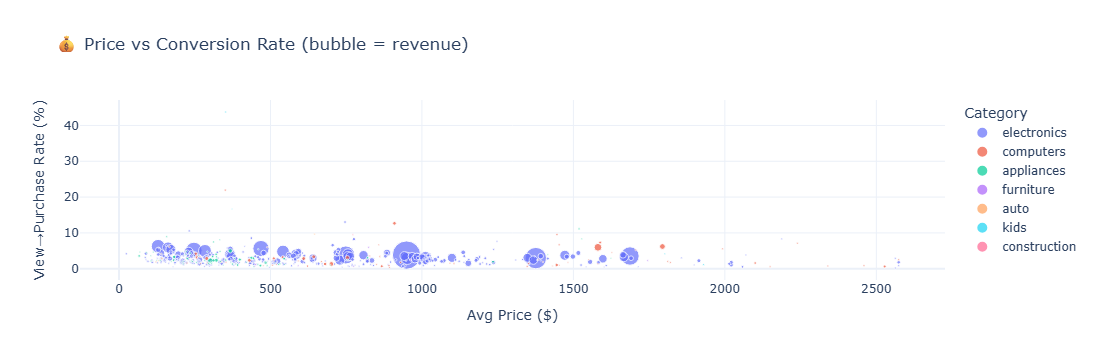

  💾 Saved: reports/figures/06_price_vs_conversion.html

🔍 Correlation (price vs conversion): -0.048
   Negative = cheaper products convert better
   Positive = higher-priced products convert better
   Near 0   = price alone doesn't explain conversion


In [9]:
# ============================================================
# STEP 3C - Price vs Conversion scatter (product level)
# Business Q: Do cheaper products convert better?
# ============================================================

df_scatter = read_sql("""
    SELECT
        product_id,
        brand,
        category_l1,
        avg_price,
        views,
        purchases,
        total_revenue,
        view_to_purchase_rate
    FROM vw_product_performance
    WHERE views  >= 10
      AND purchases >= 1
      AND category_l1 != 'unknown'
    ORDER BY total_revenue DESC
    LIMIT 500
""")

fig6 = px.scatter(
    df_scatter,
    x       = "avg_price",
    y       = "view_to_purchase_rate",
    size    = "total_revenue",
    color   = "category_l1",
    hover_data = ["brand","purchases","views"],
    title   = "💰 Price vs Conversion Rate (bubble = revenue)",
    labels  = {
        "avg_price"             : "Avg Price ($)",
        "view_to_purchase_rate" : "View→Purchase Rate (%)",
        "category_l1"           : "Category",
    },
    opacity = 0.7,
)
fig6.update_layout(template="plotly_white")
fig6.show()
save_fig(fig6, "06_price_vs_conversion.html")

corr = df_scatter["avg_price"].corr(df_scatter["view_to_purchase_rate"])
print(f"\n🔍 Correlation (price vs conversion): {corr:.3f}")
print("   Negative = cheaper products convert better")
print("   Positive = higher-priced products convert better")
print("   Near 0   = price alone doesn't explain conversion")

In [10]:
# ============================================================
# STEP 4A - Build Cohort Table
# Cohort = month user FIRST appeared
# We track: do they come back next month?
# ============================================================

df_events = read_sql("""
    SELECT
        f.user_id,
        d.year_month        AS event_month
    FROM fact_events f
    JOIN dim_date d ON f.date_id = d.date_id
    WHERE f.event_type = 'purchase'
    GROUP BY f.user_id, d.year_month
""")

# First purchase month per user = cohort
df_cohort_base = (
    df_events
    .groupby("user_id")["event_month"]
    .min()
    .reset_index()
    .rename(columns={"event_month": "cohort_month"})
)

# Merge back
df_cohort = df_events.merge(df_cohort_base, on="user_id")

# Period index: months since first purchase
df_cohort["cohort_month"]  = pd.to_datetime(df_cohort["cohort_month"])
df_cohort["event_month"]   = pd.to_datetime(df_cohort["event_month"])
df_cohort["period_number"] = (
    (df_cohort["event_month"].dt.year  - df_cohort["cohort_month"].dt.year) * 12 +
    (df_cohort["event_month"].dt.month - df_cohort["cohort_month"].dt.month)
)

df_cohort["cohort_month_str"] = df_cohort["cohort_month"].dt.strftime("%Y-%m")

print("✅ Cohort base built")
print(f"   Unique users tracked : {df_cohort['user_id'].nunique():,}")
print(f"   Cohort months found  : {sorted(df_cohort['cohort_month_str'].unique())}")

✅ Cohort base built
   Unique users tracked : 11,698
   Cohort months found  : ['2019-10', '2019-11']


In [11]:
# ============================================================
# STEP 4B - Build Cohort Retention Matrix
# ============================================================

cohort_pivot = (
    df_cohort
    .groupby(["cohort_month_str", "period_number"])["user_id"]
    .nunique()
    .reset_index()
    .rename(columns={"user_id": "users"})
    .pivot(index="cohort_month_str",
           columns="period_number",
           values="users")
)

# Cohort sizes (period 0 = base)
cohort_sizes = cohort_pivot[0]

# Retention rates as % of cohort size
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0).round(4) * 100

print("📊 Cohort Retention Matrix (%):")
print(retention_matrix.to_string())

📊 Cohort Retention Matrix (%):
period_number         0     1
cohort_month_str             
2019-10           100.0  0.37
2019-11           100.0   NaN


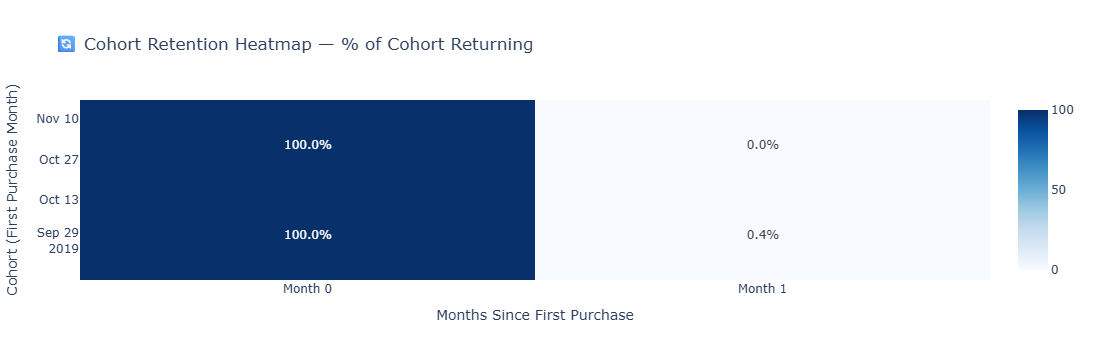

  💾 Saved: reports/figures/07_cohort_retention.html

🔍 Key Insight:
   Avg Month-1 retention : 0.4%
   ⚠️  Low retention — most users don't return after first purchase
   💡 Business opportunity: post-purchase email campaigns, loyalty program


In [12]:
# ============================================================
# STEP 4C - Plot Cohort Heatmap
# ============================================================

import plotly.figure_factory as ff

# Round for display
display_matrix = retention_matrix.round(1).fillna(0)

fig7 = go.Figure(
    data=go.Heatmap(
        z            = display_matrix.values,
        x            = [f"Month {i}" for i in display_matrix.columns],
        y            = display_matrix.index.tolist(),
        colorscale   = "Blues",
        text         = display_matrix.values,
        texttemplate = "%{text:.1f}%",
        showscale    = True,
        hoverongaps  = False,
    )
)

fig7.update_layout(
    title    = "🔄 Cohort Retention Heatmap — % of Cohort Returning",
    xaxis    = dict(title="Months Since First Purchase"),
    yaxis    = dict(title="Cohort (First Purchase Month)"),
    template = "plotly_white",
)

fig7.show()
save_fig(fig7, "07_cohort_retention.html")

# ── Key retention insight ──
if 1 in retention_matrix.columns:
    avg_m1_retention = retention_matrix[1].mean()
    print(f"\n🔍 Key Insight:")
    print(f"   Avg Month-1 retention : {avg_m1_retention:.1f}%")
    if avg_m1_retention < 10:
        print("   ⚠️  Low retention — most users don't return after first purchase")
        print("   💡 Business opportunity: post-purchase email campaigns, loyalty program")
    else:
        print("   ✅ Healthy retention signal")

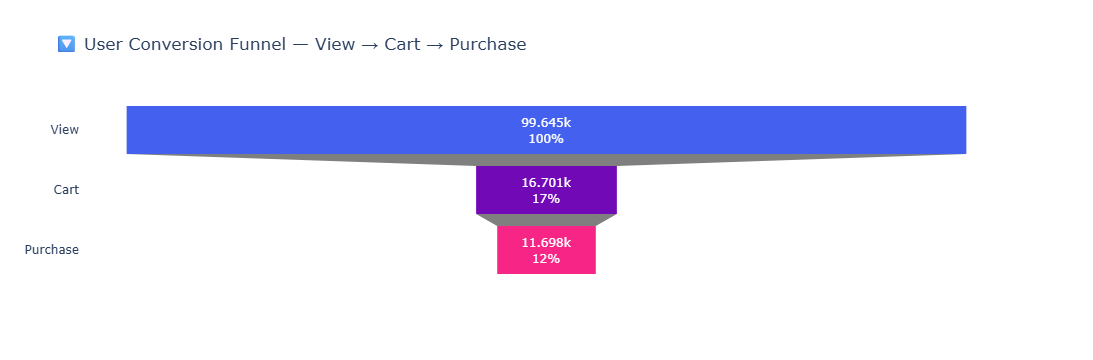

  💾 Saved: reports/figures/08_conversion_funnel.html

📊 Funnel Summary:
   view      :   99,645 users  (drop-off from top: 0.0%)
   cart      :   16,701 users  (drop-off from top: 83.2%)
   purchase  :   11,698 users  (drop-off from top: 88.3%)


In [13]:
# ============================================================
# STEP 5 - Funnel Chart (portfolio highlight)
# ============================================================

df_funnel = read_sql("""
    SELECT
        event_type,
        COUNT(DISTINCT user_id) AS unique_users
    FROM fact_events
    GROUP BY event_type
    ORDER BY FIELD(event_type, 'view', 'cart', 'purchase')
""")

# Force correct funnel order
order_map = {"view": 0, "cart": 1, "purchase": 2}
df_funnel["order"] = df_funnel["event_type"].map(order_map)
df_funnel = df_funnel.sort_values("order")

# Drop-off rates
df_funnel["dropoff_pct"] = (
    1 - df_funnel["unique_users"] / df_funnel["unique_users"].iloc[0]
) * 100

fig8 = go.Figure(go.Funnel(
    y           = df_funnel["event_type"].str.capitalize(),
    x           = df_funnel["unique_users"],
    textinfo    = "value+percent initial",
    marker      = dict(color=["#4361ee","#7209b7","#f72585"]),
))

fig8.update_layout(
    title    = "🔽 User Conversion Funnel — View → Cart → Purchase",
    template = "plotly_white",
)

fig8.show()
save_fig(fig8, "08_conversion_funnel.html")

print("\n📊 Funnel Summary:")
for _, row in df_funnel.iterrows():
    print(f"   {row['event_type']:<10}: {row['unique_users']:>8,} users  "
          f"(drop-off from top: {row['dropoff_pct']:.1f}%)")

In [14]:
# ============================================================
# STEP 6 - Save key DataFrames for Phase 7 + Power BI
# ============================================================

EXPORT_DIR = os.path.join(BASE_DIR, "data", "exports")

exports = {
    "analysis_monthly.csv"    : df_monthly,
    "analysis_daily.csv"      : df_daily,
    "analysis_hourly.csv"     : df_hourly,
    "analysis_categories.csv" : df_cat,
    "analysis_brands.csv"     : df_brand,
    "analysis_cohort.csv"     : retention_matrix.reset_index(),
    "analysis_funnel.csv"     : df_funnel,
}

print("💾 Saving analysis outputs...\n")
for fname, df_out in exports.items():
    path = os.path.join(EXPORT_DIR, fname)
    df_out.to_csv(path, index=False)
    print(f"  ✅ {fname}  ({df_out.shape[0]} rows)")

print(f"\n✅ All outputs saved to data/exports/")
print(f"🎯 8 charts saved to reports/figures/")

💾 Saving analysis outputs...

  ✅ analysis_monthly.csv  (2 rows)
  ✅ analysis_daily.csv  (61 rows)
  ✅ analysis_hourly.csv  (24 rows)
  ✅ analysis_categories.csv  (10 rows)
  ✅ analysis_brands.csv  (10 rows)
  ✅ analysis_cohort.csv  (2 rows)
  ✅ analysis_funnel.csv  (3 rows)

✅ All outputs saved to data/exports/
🎯 8 charts saved to reports/figures/
